# Notebook 03 — Análisis Semántico con Word2Vec
## Representaciones vectoriales estáticas sobre letras musicales

**Proyecto 2:** Análisis Semántico de Letras Musicales  
**Curso:** Minería de Textos — Colegio Universitario de Cartago (CUC)  


---
## 1. Imports y configuración

In [16]:
import warnings, os, re, sys
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.spatial.distance import cosine
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from pymongo import UpdateOne

from src.data.mongo_storage import get_collection

# Directorio de modelos
MODELS = Path('../data/models')
MODELS.mkdir(parents=True, exist_ok=True)

# Estética global
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print('✓ Imports OK')


✓ Imports OK


---
## 2. Carga del corpus desde MongoDB


In [17]:
# Conexión a MongoDB a través de mongo_storage
try:
    coleccion = get_collection()   # uri/db/col por defecto: localhost/musica/canciones
    coleccion.database.client.admin.command('ping')
    print('✓ Conexión a MongoDB OK')
except Exception as e:
    raise RuntimeError(
        f'No se pudo conectar a MongoDB: {e}\n'
        '  Verificá que mongod esté corriendo en localhost:27017'
    ) from e

# Diagnóstico previo
total_docs = coleccion.count_documents({})
con_pos    = coleccion.count_documents({'pos_tags.spacy': {'$ne': None}})
print(f'  Documentos en colección : {total_docs:,}')
print(f'  Con pos_tags.spacy      : {con_pos:,}')

if con_pos == 0:
    raise RuntimeError(
        'No hay documentos con pos_tags.spacy.\n'
        '  Ejecutá primero el notebook P02_01/P02_02 para generar los POS-tags.'
    )

docs = list(coleccion.find(
    {'pos_tags.spacy': {'$ne': None}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1, 'Song year': 1, 'pos_tags': 1}
))
df = pd.DataFrame(docs).dropna(subset=['Genre']).copy()

df['pos_tags_spacy'] = df['pos_tags'].apply(
    lambda x: x.get('spacy', []) if isinstance(x, dict) else []
)
df = df[df['pos_tags_spacy'].apply(len) > 0].reset_index(drop=True)

# Géneros detectados dinámicamente del dataset
conteo  = df['Genre'].value_counts()
GENEROS = conteo[conteo >= 20].index.tolist()
df      = df[df['Genre'].isin(GENEROS)].reset_index(drop=True)

print(f'\n✓ {len(df):,} canciones | {len(GENEROS)} géneros con ≥20 canciones')
print()
print(df['Genre'].value_counts().to_string())


✓ Conexión a MongoDB OK
  Documentos en colección : 9,246
  Con pos_tags.spacy      : 9,246

✓ 9,246 canciones | 10 géneros con ≥20 canciones

Genre
Rock          1410
Pop           1307
Hip-Hop       1159
Country       1010
Metal         1009
Jazz           855
Electronic     810
R&B            681
Indie          510
Folk           495


---
## 3. Tokenización y limpieza desde `pos_tags`


In [18]:
import subprocess, spacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('Descargando en_core_web_sm...')
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')

STOPWORDS = nlp.Defaults.stop_words

PATRON_FRAGMENTO = re.compile(
    r'^(didn|couldn|wouldn|shouldn|won|don|isn|aren|wasn|weren|haven|hadn'
    r'|aint|wont|cant|gon|cause|ill|em|im|ur|ya|yer|ol|th|ve|re|ll|nd|nt)$'
)

def tokens_limpios(pos_tags: list) -> list:
    tokens = []
    for t in pos_tags:
        if t.get('pos') in ('PUNCT', 'SPACE', 'SYM', 'NUM', 'X', 'PROPN'):
            continue
        lemma = t.get('lemma', '').lower().strip()
        if not lemma or len(lemma) < 3:            continue
        if lemma in STOPWORDS:                     continue
        if re.search(r'(.)\1{3,}', lemma):         continue
        if PATRON_FRAGMENTO.match(lemma):          continue
        if re.search(r'\d', lemma):                continue
        tokens.append(lemma)
    return tokens


df['tokens_w2v'] = df['pos_tags_spacy'].apply(tokens_limpios)
corpus_tokens    = df['tokens_w2v'].tolist()

total  = sum(len(t) for t in corpus_tokens)
unicos = len(set(t for toks in corpus_tokens for t in toks))

print(f'✓ {total:,} tokens totales | {unicos:,} lemas únicos')
print(f'✓ spaCy cargado — {len(STOPWORDS)} stopwords\n')
top20 = Counter(t for toks in corpus_tokens for t in toks).most_common(20)
print('Top 20 tokens más frecuentes (verificación de calidad):')
for tok, n in top20:
    print(f'  {tok:<20} {n:>6}')

✓ 855,917 tokens totales | 28,903 lemas únicos
✓ spaCy cargado — 326 stopwords

Top 20 tokens más frecuentes (verificación de calidad):
  know                  16464
  like                  15349
  love                  15297
  come                   9057
  yeah                   8962
  time                   8395
  want                   7781
  let                    6850
  feel                   6278
  way                    6208
  tell                   6166
  think                  5205
  baby                   5148
  day                    5012
  need                   4983
  right                  4888
  life                   4885
  heart                  4628
  look                   4573
  night                  4444


---
## 4. Entrenamiento Word2Vec — CBOW y Skip-Gram


### 4.1 Modelos globales (corpus completo)

In [19]:
PARAMS = dict(vector_size=100, window=5, min_count=5, epochs=20, seed=42, workers=4)

print('Entrenando modelos globales...')
w2v_cbow = Word2Vec(corpus_tokens, sg=0, **PARAMS)
w2v_sg   = Word2Vec(corpus_tokens, sg=1, **PARAMS)

w2v_cbow.save(str(MODELS / 'w2v_cbow_global.model'))
w2v_sg.save(str(MODELS / 'w2v_skipgram_global.model'))

print(f'  ✓ CBOW global      — vocabulario: {len(w2v_cbow.wv):,} palabras')
print(f'  ✓ Skip-Gram global — vocabulario: {len(w2v_sg.wv):,} palabras')
print(f'  ✓ Modelos guardados en {MODELS}')

Entrenando modelos globales...
  ✓ CBOW global      — vocabulario: 8,369 palabras
  ✓ Skip-Gram global — vocabulario: 8,369 palabras
  ✓ Modelos guardados en ..\data\models


### 4.2 Modelos por género


In [20]:
PARAMS_G = dict(vector_size=100, window=5, min_count=3, epochs=20, seed=42, workers=4)

modelos_cbow = {}   # { genero: modelo_cbow }
modelos_sg   = {}   # { genero: modelo_skipgram }
corpus_g     = {}   # { genero: lista_de_tokens }

print('Entrenando modelos por género...')
for genero in GENEROS:
    toks_g = df[df['Genre'] == genero]['tokens_w2v'].tolist()
    n_tok  = sum(len(t) for t in toks_g)

    if len(toks_g) < 10 or n_tok < 500:
        print(f'  {genero:<14} — muy pocos tokens, omitido')
        continue

    corpus_g[genero]     = toks_g
    modelos_cbow[genero] = Word2Vec(toks_g, sg=0, **PARAMS_G)
    modelos_sg[genero]   = Word2Vec(toks_g, sg=1, **PARAMS_G)

    slug = genero.replace(' ', '_').replace('-', '_').lower()
    modelos_cbow[genero].save(str(MODELS / f'w2v_cbow_{slug}.model'))
    modelos_sg[genero].save(str(MODELS / f'w2v_skipgram_{slug}.model'))

    print(f'  ✓ {genero:<14} — CBOW: {len(modelos_cbow[genero].wv):,} | '
          f'Skip-Gram: {len(modelos_sg[genero].wv):,} palabras | {len(toks_g)} canciones')

GENEROS_OK = list(modelos_cbow.keys())
print(f'\n✓ {len(GENEROS_OK) * 2} modelos por género entrenados y guardados')

Entrenando modelos por género...
  ✓ Rock           — CBOW: 3,032 | Skip-Gram: 3,032 palabras | 1410 canciones
  ✓ Pop            — CBOW: 3,071 | Skip-Gram: 3,071 palabras | 1307 canciones
  ✓ Hip-Hop        — CBOW: 5,760 | Skip-Gram: 5,760 palabras | 1159 canciones
  ✓ Country        — CBOW: 2,408 | Skip-Gram: 2,408 palabras | 1010 canciones
  ✓ Metal          — CBOW: 3,458 | Skip-Gram: 3,458 palabras | 1009 canciones
  ✓ Jazz           — CBOW: 2,595 | Skip-Gram: 2,595 palabras | 855 canciones
  ✓ Electronic     — CBOW: 2,384 | Skip-Gram: 2,384 palabras | 810 canciones
  ✓ R&B            — CBOW: 2,237 | Skip-Gram: 2,237 palabras | 681 canciones
  ✓ Indie          — CBOW: 1,657 | Skip-Gram: 1,657 palabras | 510 canciones
  ✓ Folk           — CBOW: 1,943 | Skip-Gram: 1,943 palabras | 495 canciones

✓ 20 modelos por género entrenados y guardados


---
## 5. Exploración semántica — vecinos por género


In [21]:
PALABRAS_TEST = ['love', 'fight', 'night', 'money', 'soul', 'fire', 'road', 'dark']

print('=== Vecinos semánticos — Skip-Gram por género ===\n')
for palabra in PALABRAS_TEST:
    encontrado = False
    lineas = []
    for genero in GENEROS_OK:
        wv = modelos_sg[genero].wv
        if palabra not in wv:
            continue
        encontrado = True
        vecinos = wv.most_similar(palabra, topn=5)
        vstr    = ', '.join(f'{w} ({s:.2f})' for w, s in vecinos)
        lineas.append(f'  {genero:<14} → {vstr}')
    if encontrado:
        print(f'--- "{palabra}" ---')
        print('\n'.join(lineas))


=== Vecinos semánticos — Skip-Gram por género ===

--- "love" ---
  Rock           → tenderly (0.56), peacefully (0.55), agonna (0.55), know (0.53), understanding (0.53)
  Pop            → know (0.57), rediscover (0.56), symmetrical (0.55), untrue (0.55), unsure (0.54)
  Hip-Hop        → lalalalala (0.72), ppose (0.72), complicated (0.71), spending (0.71), wussup (0.70)
  Country        → understanding (0.64), eternally (0.60), aside (0.56), habit (0.55), lasting (0.55)
  Metal          → frenchfrye (0.73), tempting (0.67), steak (0.66), ohoh (0.66), peacock (0.66)
  Jazz           → supreme (0.68), complicate (0.57), madly (0.56), turtledove (0.54), expect (0.54)
  Electronic     → want (0.52), honestly (0.51), heart (0.49), guessin (0.49), ruin (0.49)
  R&B            → nuff (0.53), pure (0.53), complicate (0.53), conform (0.52), thotful (0.50)
  Indie          → stole (0.65), darlin (0.59), beyonce (0.59), reputation (0.58), persuasion (0.58)
  Folk           → tug (0.62), united (0

### Similitud directa entre pares de palabras por género

In [22]:
PARES = [('sad', 'pain'), ('love', 'heart'), ('money', 'power'), ('fire', 'burn')]

col_header = '  '.join(f'{g[:8]:<8}' for g in GENEROS_OK)
print(f'{"Par":<22}  {col_header}')
print('-' * (24 + len(GENEROS_OK) * 11))

for w1, w2 in PARES:
    scores = []
    for genero in GENEROS_OK:
        wv = modelos_sg[genero].wv
        scores.append(f'{wv.similarity(w1, w2):.4f}' if w1 in wv and w2 in wv else '  N/A  ')
    print(f"  {f'{w1!r} ↔ {w2!r}':<20}  {'  '.join(scores)}")

Par                     Rock      Pop       Hip-Hop   Country   Metal     Jazz      Electron  R&B       Indie     Folk    
--------------------------------------------------------------------------------------------------------------------------------------
  'sad' ↔ 'pain'        0.1901  0.1788  0.2670  0.2185  0.2767  0.2837  0.2315  0.3818  0.1303  0.2523
  'love' ↔ 'heart'      0.4043  0.3929  0.5027  0.4877  0.2678  0.4834  0.4924  0.1692  0.3072  0.4334
  'money' ↔ 'power'     0.2521  0.2340  0.2536  0.1299  0.1792  0.1440  0.0832  0.3691  0.1703  0.4887
  'fire' ↔ 'burn'       0.4571  0.4182  0.5292  0.3933  0.4375  0.4542  0.3911  0.4484  0.4281  0.6082


### Vocabulario top por género (Skip-Gram)

In [23]:
TOP_N = 10
print(f'=== Top {TOP_N} palabras más frecuentes por género ===\n')
for genero in GENEROS_OK:
    todas  = [t for toks in corpus_g[genero] for t in toks]
    top    = Counter(todas).most_common(TOP_N)
    topstr = ', '.join(f'{w} ({n})' for w, n in top)
    print(f'  {genero:<14} → {topstr}')

=== Top 10 palabras más frecuentes por género ===

  Rock           → know (1840), love (1481), like (1402), come (1199), time (1153), want (989), way (847), feel (811), day (779), let (682)
  Pop            → love (3406), know (3044), like (2486), want (1559), yeah (1502), come (1366), time (1350), let (1264), feel (1261), way (1107)
  Hip-Hop        → like (5442), know (3532), yeah (2875), shit (2046), bitch (2004), nigga (1988), come (1802), love (1785), fuck (1677), want (1659)
  Country        → love (1683), know (1542), like (1194), time (886), yeah (794), come (743), way (693), little (661), good (636), think (564)
  Metal          → know (811), life (767), time (722), like (671), come (667), away (551), die (534), feel (533), eye (533), world (509)
  Jazz           → love (1853), know (1162), like (844), come (788), time (571), way (563), heart (517), want (515), day (514), tell (507)
  Electronic     → love (1437), know (1340), like (1189), come (922), let (807), feel (788), w

---
## 6. Analogías vectoriales


In [24]:
def analogia(positivos, negativos, modelo, top_n=3):
    ausentes = [w for w in positivos + negativos if w not in modelo.wv]
    if ausentes:
        return None, ausentes
    excluir = set(positivos + negativos)
    raw     = modelo.wv.most_similar(positive=positivos, negative=negativos,
                                     topn=top_n + len(excluir))
    return [(w, s) for w, s in raw if w not in excluir][:top_n], []


ANALOGIAS = [
    (['love', 'happy'],   ['sad'],     'love + happy − sad'),
    (['night', 'dark'],   ['day'],     'night + dark − day'),
    (['king', 'woman'],   ['man'],     'king + woman − man   (→ queen?)'),
    (['dance', 'music'],  ['silence'], 'dance + music − silence'),
    (['broken', 'heart'], ['happy'],   'broken + heart − happy'),
]

for genero in GENEROS_OK:
    ejecutadas = 0
    lineas = []
    for pos, neg, desc in ANALOGIAS:
        res, ausentes = analogia(pos, neg, modelos_sg[genero])
        if ausentes:
            continue
        ejecutadas += 1
        rstr = ', '.join(f'{w} ({s:.3f})' for w, s in res)
        lineas.append(f'  {desc:<38} → {rstr}')
    if ejecutadas:
        print(f'=== {genero.title()} (Skip-Gram) ===')
        print('\n'.join(lineas))


=== Rock (Skip-Gram) ===
  love + happy − sad                     → know (0.484), month (0.433), universe (0.427)
  night + dark − day                     → spark (0.459), coal (0.446), fog (0.411)
  king + woman − man   (→ queen?)        → kane (0.462), unsung (0.441), crown (0.440)
  dance + music − silence                → reminisce (0.489), hillbilly (0.472), forseen (0.471)
  broken + heart − happy                 → attack (0.541), display (0.502), beating (0.486)

=== Pop (Skip-Gram) ===
  love + happy − sad                     → patient (0.482), loves (0.474), saidyou (0.472)
  night + dark − day                     → private (0.507), spark (0.488), vapor (0.456)
  king + woman − man   (→ queen?)        → lowly (0.471), spring (0.448), threat (0.447)
  dance + music − silence                → steppin (0.529), distortion (0.528), sunrise (0.521)
  broken + heart − happy                 → mend (0.546), apart (0.539), decline (0.503)

=== Hip-Hop (Skip-Gram) ===
  love + happy − sa

---
## 7. Similitud entre géneros — vectores centroide


### 7.1 Modelo CBOW

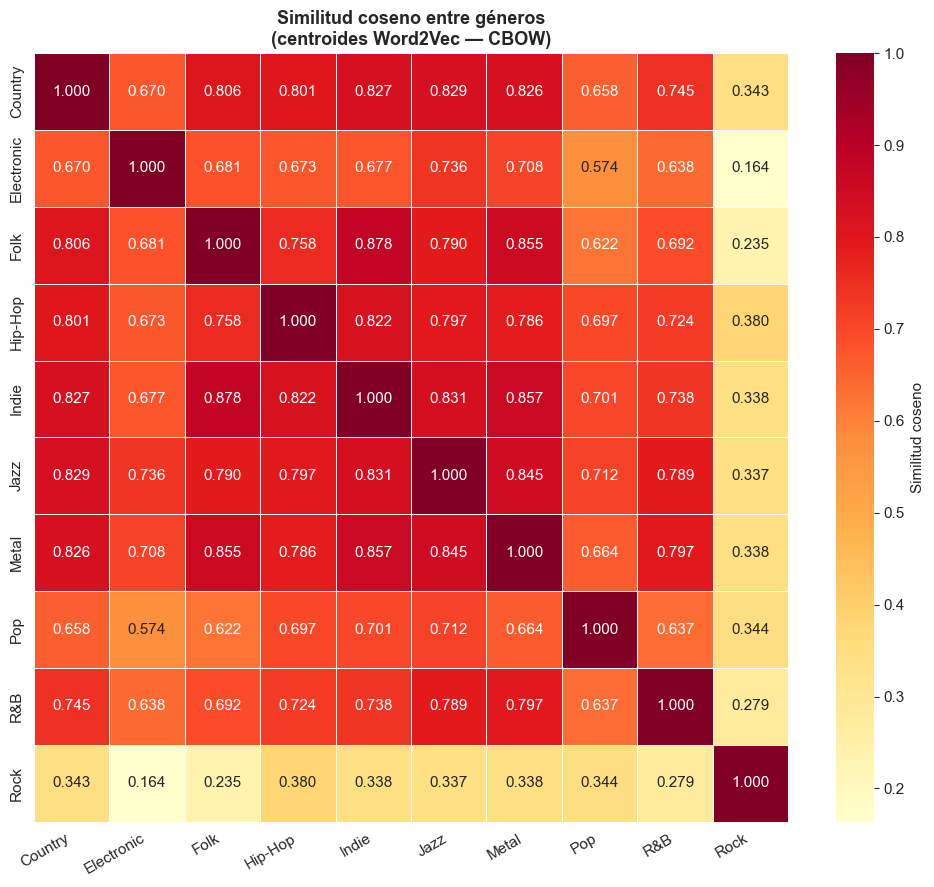

Top 3 más SIMILARES:
  Folk ↔ Indie: 0.8778
  Indie ↔ Metal: 0.8568
  Folk ↔ Metal: 0.8546
Top 3 más DIFERENTES:
  R&B ↔ Rock: 0.2786
  Folk ↔ Rock: 0.2347
  Electronic ↔ Rock: 0.1639



In [25]:
def heatmap_similitud(modelos, corpus_g, titulo):
    generos_ord = sorted(modelos.keys())
    n           = len(generos_ord)

    centroides = {}
    for g in generos_ord:
        vecs = [modelos[g].wv[t] for toks in corpus_g[g] for t in toks if t in modelos[g].wv]
        centroides[g] = np.mean(vecs, axis=0) if vecs else np.zeros(100)

    sim = np.zeros((n, n))
    for i, g1 in enumerate(generos_ord):
        for j, g2 in enumerate(generos_ord):
            sim[i, j] = 1 - cosine(centroides[g1], centroides[g2])

    mask = np.eye(n, dtype=bool)
    fig, ax = plt.subplots(figsize=(max(7, n), max(5, n - 1)))
    sns.heatmap(sim, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=generos_ord, yticklabels=generos_ord,
                vmin=sim[~mask].min(), vmax=1.0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Similitud coseno'})
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    pares = [(sim[i,j], generos_ord[i], generos_ord[j])
             for i in range(n) for j in range(i+1, n)]
    pares.sort(reverse=True)
    print('Top 3 más SIMILARES:')
    for s, g1, g2 in pares[:3]:  print(f'  {g1} ↔ {g2}: {s:.4f}')
    print('Top 3 más DIFERENTES:')
    for s, g1, g2 in pares[-3:]: print(f'  {g1} ↔ {g2}: {s:.4f}')
    print()
    return centroides


centroides_cbow = heatmap_similitud(
    modelos_cbow, corpus_g,
    'Similitud coseno entre géneros\n(centroides Word2Vec — CBOW)'
)

### 7.2 Modelo Skip-Gram

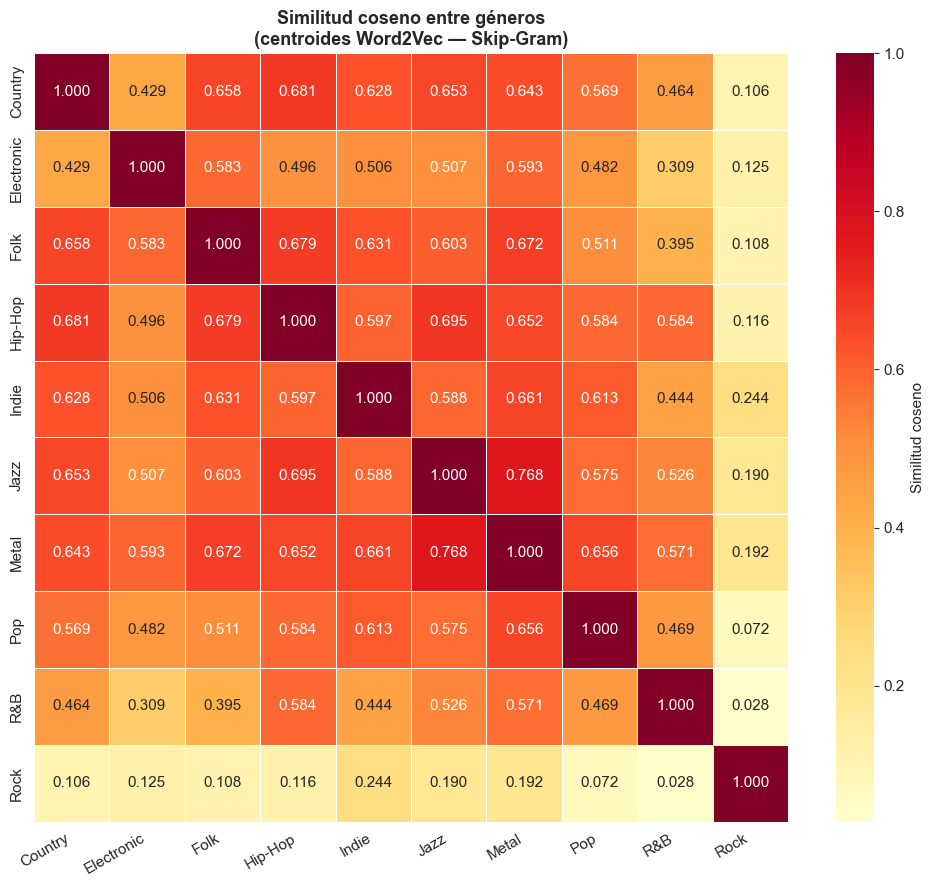

Top 3 más SIMILARES:
  Jazz ↔ Metal: 0.7685
  Hip-Hop ↔ Jazz: 0.6954
  Country ↔ Hip-Hop: 0.6813
Top 3 más DIFERENTES:
  Country ↔ Rock: 0.1059
  Pop ↔ Rock: 0.0720
  R&B ↔ Rock: 0.0281



In [26]:
centroides_sg = heatmap_similitud(
    modelos_sg, corpus_g,
    'Similitud coseno entre géneros\n(centroides Word2Vec — Skip-Gram)'
)

---
## 8. Proyección t-SNE del espacio semántico

Proyectamos los embeddings de palabras clave a **2 dimensiones** para verificar  
visualmente que los clusters semánticos son coherentes.

> Palabras del mismo grupo semántico deben aparecer **cerca** en el espacio proyectado.

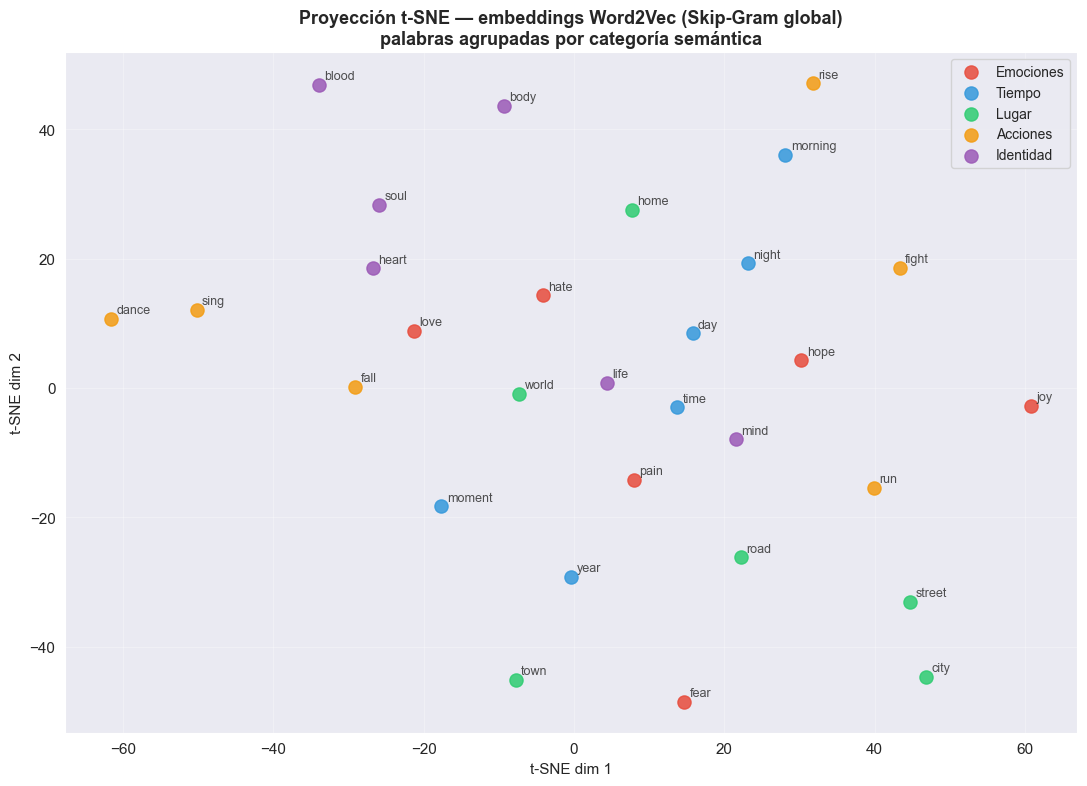

In [31]:
GRUPOS = {
    'Emociones':  ['love', 'hate', 'fear', 'joy', 'pain', 'hope'],
    'Tiempo':     ['night', 'day', 'morning', 'year', 'time', 'moment'],
    'Lugar':      ['road', 'street', 'home', 'town', 'city', 'world'],
    'Acciones':   ['fight', 'run', 'dance', 'sing', 'fall', 'rise'],
    'Identidad':  ['heart', 'soul', 'mind', 'body', 'life', 'blood'],
}
COLORES_GRUPO = {
    'Emociones': '#e74c3c', 'Tiempo': '#3498db', 'Lugar':  '#2ecc71',
    'Acciones':  '#f39c12', 'Identidad': '#9b59b6',
}

palabras_plot, vectores_plot, cats_plot = [], [], []
for cat, palabras in GRUPOS.items():
    for p in palabras:
        if p in w2v_sg.wv:
            palabras_plot.append(p)
            vectores_plot.append(w2v_sg.wv[p])
            cats_plot.append(cat)

if len(vectores_plot) >= 5:
    tsne   = TSNE(n_components=2, random_state=42,
                  perplexity=min(5, len(vectores_plot) - 1))
    coords = tsne.fit_transform(np.array(vectores_plot))

    fig, ax = plt.subplots(figsize=(11, 8))
    for cat in GRUPOS:
        idxs = [i for i, c in enumerate(cats_plot) if c == cat]
        ax.scatter(coords[idxs, 0], coords[idxs, 1],
                   color=COLORES_GRUPO[cat], s=90, label=cat, alpha=0.85, zorder=3)
        for i in idxs:
            ax.annotate(palabras_plot[i], (coords[i, 0], coords[i, 1]),
                        fontsize=9, alpha=0.8, xytext=(4, 4), textcoords='offset points')

    ax.set_title('Proyección t-SNE — embeddings Word2Vec (Skip-Gram global)\n'
                 'palabras agrupadas por categoría semántica',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    plt.tight_layout()
    plt.show()
else:
    print('⚠ Pocas palabras en vocabulario para t-SNE. Reducir min_count.')

---
## 9. Vocabulario exclusivo por género


In [28]:
def calcular_centroides(generos, corpus_g, modelo):
    out = {}
    for g in generos:
        vecs = [modelo.wv[t] for toks in corpus_g[g] for t in toks if t in modelo.wv]
        if vecs:
            out[g] = np.mean(vecs, axis=0)
    return out

def palabras_exclusivas(genero_obj, centroides, modelo, top_k=10):
    c_obj   = centroides[genero_obj]
    c_otros = [c for g, c in centroides.items() if g != genero_obj]
    resultados = []
    for palabra in modelo.wv.index_to_key:
        vec       = modelo.wv[palabra]
        sim_obj   = 1 - cosine(vec, c_obj)
        sim_otros = max(1 - cosine(vec, c) for c in c_otros)
        margen    = sim_obj - sim_otros
        if margen > 0:
            resultados.append((palabra, round(sim_obj, 4), round(margen, 4)))
    resultados.sort(key=lambda x: -x[2])
    return resultados[:top_k]


centroides_exc = calcular_centroides(GENEROS_OK, corpus_g, w2v_sg)

print('=== Vocabulario exclusivo por género (Top 10 palabras) ===\n')
vocab_exclusivo = {}
for genero in GENEROS_OK:
    excl = palabras_exclusivas(genero, centroides_exc, w2v_sg, top_k=10)
    vocab_exclusivo[genero] = excl
    pstr = ', '.join(p for p, _, _ in excl)
    print(f'  {genero.title():<14} → {pstr}')

=== Vocabulario exclusivo por género (Top 10 palabras) ===

  Rock           → scared, furth, climax, awaydont, ahead, better, blame, unsaid, miracle, security
  Pop            → desperately, loves, love, lasting, perfect, closely, easily, ohhh, oohoohooh, superfine
  Hip-Hop        → pokin, jackin, afro, rookie, gutta, asse, slingin, bronx, fakeass, loc
  Country        → rodeo, rambler, hangup, suitcase, beer, drive, town, cowboy, daisy, pronounce
  Metal          → damnation, infliction, destructive, infest, wickedness, terrifying, morbid, avenge, religious, condemn
  Jazz           → confidentially, schon, mir, bist, quiero, embraceable, opening, composer, sweet, beyonce
  Electronic     → evacuate, rev, celebrate, longly, robot, shshake, fuzzy, hollywood, stop, privately
  R&B            → reunion, alwayz, freakydicky, babybaby, shiftin, girl, woah, lifesaver, braver, dontcha
  Indie          → bedroom, wrap, cle, asleep, waterfall, diary, gig, sleep, puzzle, quiet
  Folk         

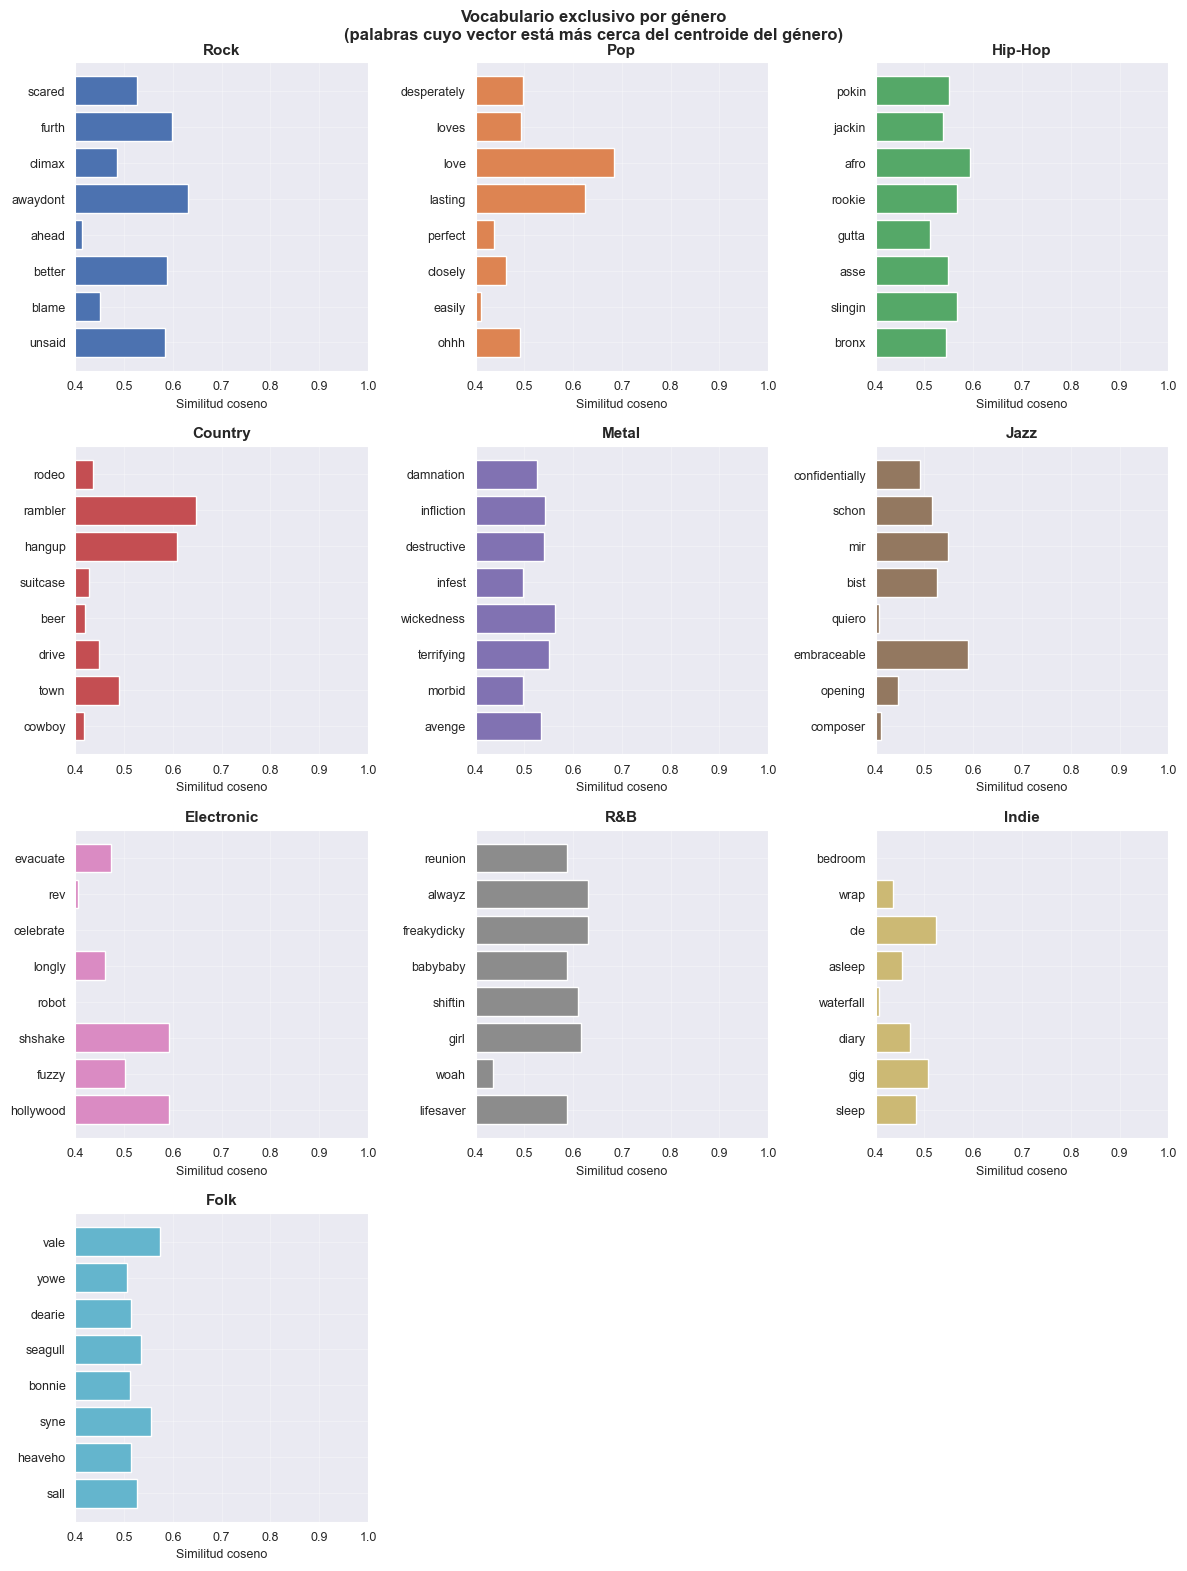

In [29]:
# Grilla dinámica de barras — se adapta a cualquier cantidad de géneros
n_g   = len(GENEROS_OK)
ncols = min(3, n_g)
nrows = (n_g + ncols - 1) // ncols
pal   = (PALETTE * ((n_g // len(PALETTE)) + 1))[:n_g]

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = np.array(axes).flatten()

for ax, genero, color in zip(axes, GENEROS_OK, pal):
    datos = vocab_exclusivo.get(genero, [])[:8]
    if not datos:
        ax.axis('off')
        continue
    pals   = [d[0] for d in datos]
    scores = [d[1] for d in datos]
    ax.barh(pals[::-1], scores[::-1], color=color, edgecolor='white')
    ax.set_title(genero.title(), fontsize=11, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel('Similitud coseno', fontsize=9)
    ax.tick_params(labelsize=9)

for ax in axes[n_g:]:
    ax.axis('off')

plt.suptitle(
    'Vocabulario exclusivo por género\n'
    '(palabras cuyo vector está más cerca del centroide del género)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## 10. Guardar embeddings en MongoDB


In [30]:
def w2v_promedio(tokens, modelo):
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    return np.mean(vecs, axis=0).tolist() if vecs else None


# coleccion ya fue obtenida en la celda de carga mediante get_collection()
print('Guardando embeddings Word2Vec en MongoDB...')
print('Estrategia: $mergeObjects sobre embeddings.word2vec_avg (no toca beto_cls ni otros campos)\n')

operaciones = []
sin_vector  = 0

for _, row in df.iterrows():
    emb = w2v_promedio(row['tokens_w2v'], w2v_sg)
    if emb is None:
        sin_vector += 1
        continue
    operaciones.append(
        UpdateOne(
            {'_id': row['_id']},
            [{'$set': {
                'embeddings': {
                    '$mergeObjects': [
                        {'$ifNull': ['$embeddings', {}]},
                        {'word2vec_avg': emb}
                    ]
                }
            }}],
            upsert=False
        )
    )

LOTE      = 500
guardados = 0
errores   = 0

for i in range(0, len(operaciones), LOTE):
    lote = operaciones[i: i + LOTE]
    try:
        r          = coleccion.bulk_write(lote, ordered=False)
        guardados += r.modified_count
    except Exception as e:
        errores += len(lote)
        print(f'  ERROR en lote {i // LOTE + 1}: {e}')
    done = min(i + LOTE, len(operaciones))
    print(f'\r  {done}/{len(operaciones)} enviadas — modificadas: {guardados}',
          end='', flush=True)

print(f'\n\nembeddings.word2vec_avg actualizado: {guardados}/{len(df)} canciones')
if sin_vector: print(f'  Sin vector (tokens fuera de vocabulario): {sin_vector}')
if errores:    print(f'  ADVERTENCIA: {errores} operaciones fallidas')

# Verificacion rapida
sample = coleccion.find_one(
    {'_id': df.iloc[0]['_id']},
    {'embeddings.word2vec_avg': 1}
)
if sample and sample.get('embeddings', {}).get('word2vec_avg'):
    dim = len(sample['embeddings']['word2vec_avg'])
    print(f'  Verificacion OK — dimension del vector almacenado: {dim}')
else:
    print('  Verificacion fallida — revisa la conexion a MongoDB')

Guardando embeddings Word2Vec en MongoDB...
Estrategia: $mergeObjects sobre embeddings.word2vec_avg (no toca beto_cls ni otros campos)

  9241/9241 enviadas — modificadas: 9241

embeddings.word2vec_avg actualizado: 9241/9246 canciones
  Sin vector (tokens fuera de vocabulario): 5
  Verificacion OK — dimension del vector almacenado: 100
